In [11]:
from __future__ import division

from builtins import str
from builtins import range
import time
import numpy as np
import scipy as sp
import nestkit as nestkit
import read_cia
import TPmod
import settings
import os
import gc
import sys
import pickle
from scipy import interpolate
from scipy.interpolate import interp1d
from scipy.interpolate import InterpolatedUnivariateSpline
from numba import jit
import cloudnest
from sizes import *
from phys_const import *
import read_cia

In [12]:
runname = "0359_JIT_Test"

obspec = np.loadtxt("0359.txt",dtype='d',unpack=True)

w1 = 0.9
w2 = 12.0

fwhm = 999

dist = 13.57 # Is a retrieved parameter with Gaussian priors
dist_err = 0.37

npatches = 1
nclouds = 1

do_clouds = np.zeros([npatches],dtype='i')

do_clouds[:] = 0

cloudnum = np.zeros([npatches,nclouds],dtype='i')
cloudtype =np.zeros([npatches,nclouds],dtype='i')

cloudtype[:,0] = 1

chemeq = 0

do_bff = 0

proftype = 1
pfile = "t400g562nc_m+0.5.dat"

knots = 5

logcoarsePress = np.linspace(-4.0, 2.4, knots)
logfinePress = np.arange(-4.0, 2.4, 0.1)

# forward model wants pressure in bar
#logcoarsePress = np.arange(-4.0, 3.0, 0.5)
coarsePress = pow(10,logcoarsePress)
press = pow(10,logfinePress)

xpath = "/Users/harshil/PycharmProjects/Brewster/Brewster_local/Linelists/"
xlist = 'gaslistR10K.dat'

gaslist = ['h2o','ch4','co','co2','nh3','h2s','Na','K', 'ph3']

ngas = len(gaslist)

malk = 1

make_arg_pickle = 2

outdir = "/Users/harshil/PycharmProjects/Brewster/Brewster_local/Output/"

finalout = runname+".pk1"

# use the fudge factor?
do_fudge = 1

prof = np.full(5, 100.)
if (proftype == 9):
    modP, modT = np.loadtxt(pfile, skiprows=1, usecols=(1, 2), unpack=True)
    tfit = InterpolatedUnivariateSpline(np.log10(modP), modT, k=1)
    prof = tfit(logcoarsePress)

# Now we'll get the opacity files into an array
inlinetemps, inwavenum, linelist, gasnum, nwave = nestkit.get_opacities(gaslist, w1, w2, press, xpath, xlist, malk)

# Get the cia bits
tmpcia, ciatemps = read_cia.read_cia("CIA_DS_aug_2015.dat", inwavenum, nwave)
cia = np.asarray((np.empty((4,ciatemps.size,nwave), dtype='float32')))
cia[:,:,:] = tmpcia[:,:,:nwave]
ciatemps = np.asarray(ciatemps)

# grab BFF and Chemical grids
bff_raw, ceTgrid, metscale, coscale, gases_myP = nestkit.sort_bff_and_CE(chemeq, "chem_eq_tables_P3K.pic", press,
                                                                         gaslist)

#init_all_a()

settings.init()
settings.runargs = gases_myP, chemeq, dist, dist_err, cloudtype, do_clouds, gasnum, gaslist, cloudnum, inlinetemps, coarsePress, press, inwavenum, linelist, cia, ciatemps, fwhm, obspec, proftype, do_fudge, prof, do_bff, bff_raw, ceTgrid, metscale, coscale

nlayers = press.size
nlinetemps = inlinetemps.size
npress = press.size

settings.init_number()
settings.number = nlayers, ngas, npatches, nwave, nlinetemps, nclouds, npress

# Write the arguments to a pickle if needed
if make_arg_pickle > 0:
    pickle.dump(settings.runargs, open(outdir + runname + "_runargs.pic", "wb"))
    if make_arg_pickle == 1:
        sys.exit()

# put it all together in the sampler..

n_params = nestkit.countdims(settings.runargs)

In [13]:
# This is where you setup theta
object_name = '0359'
samples = np.loadtxt(object_name + "_5_knots.txt", unpack=False)
theta = np.empty([samples.shape[1]])
for i in range(n_params):
    theta[i] = np.median(samples[:, i])

In [14]:
gnostics=0

In [15]:
if chemeq == 0:
    if (gasnum[gasnum.size - 1] == 21):
        ng = gasnum.size - 1
    elif (gasnum[gasnum.size - 1] == 23):
        ng = gasnum.size - 2
    else:
        ng = gasnum.size
    invmr = theta[0:ng]

else:
    mh = theta[0]
    co = theta[1]
    ng = 2
    mfit = interp1d(metscale, gases_myP, axis=0)
    gases_myM = mfit(mh)
    cfit = interp1d(coscale, gases_myM, axis=0)
    invmr = cfit(co)

GM = (6.67E-11 * theta[ng] * 1.898e27)
R = theta[ng + 1] * 69911e3
logg = np.log10(100. * GM / R ** 2.)

# D = (dist + (np.random.randn()*dist_err)) * 3.086e16
R2D2 = R ** 2. / theta[-6] ** 2.

dlam = theta[ng + 2]

if (do_fudge == 1):
    logf = theta[ng + 3]
    nb = 4
elif (do_fudge == 2):
    logf1 = theta[ng + 3]
    logf2 = theta[ng + 4]
    nb = 5
else:
    nb = 3

npatches = do_clouds.size
if (npatches > 1):
    prat = theta[ng + nb]
    pcover = np.array([prat, (1. - prat)])
    pc = ng + nb + 1
else:
    pc = ng + nb
    pcover = 1.0

# use correct unpack method depending on situation

if ((npatches > 1) and np.all(do_clouds != 0)):
    cloudparams, nc = cloudnest.unpack_patchy(theta, pc, cloudtype, cloudnum, do_clouds)
else:
    cloudparams, nc = cloudnest.unpack_default(theta, pc, cloudtype, cloudnum, do_clouds)

if (proftype < 8):
    intemp = theta[pc + nc + 1:]
elif (proftype == 9):
    intemp = prof
else:
    raise ValueError("not valid profile type %proftype" % (char, string))

# set the profile
temp = TPmod.set_prof(proftype, coarsePress, press, intemp)

ngas = gasnum.size
bff = np.zeros([3, nlayers], dtype="float64")

# check if its a fixed VMR or a profile from chem equilibrium
# VMR is log10(VMR) !!!
if chemeq == 1:
    # this case is a profile
    ng = invmr.shape[2]
    ngas = ng - 3
    logVMR = np.zeros([ngas, nlayers], dtype='d')
    for p in range(0, nlayers):
        for g in range(0, ng):
            tfit = InterpolatedUnivariateSpline(ceTgrid, invmr[:, p, g])
            if (g < 3):
                bff[g, p] = tfit(temp[p])
            else:
                logVMR[g - 3, p] = tfit(temp[p])
else:
    # This case is fixed VMR
    # chemeq = 0
    logVMR = np.empty((ngas, nlayers), dtype='d')
    alkratio = 16.2  # from Asplund et al (2009)

    # now sort Na and K
    # get the ngas for forward model (ngas, not ng
    if (gasnum[gasnum.size - 1] == 21):
        ngas = invmr.shape[0] + 1
    elif (gasnum[gasnum.size - 1] == 23):
        ngas = invmr.shape[0] + 2
    else:
        ngas = invmr.shape[0]

    tmpvmr = np.empty(ngas, dtype='d')
    if (gasnum[gasnum.size - 1] == 21):
        tmpvmr[0:(ngas - 2)] = invmr[0:(ngas - 2)]
        tmpvmr[ngas - 2] = np.log10(10. ** invmr[ngas - 2] / (alkratio + 1.))  # K
        tmpvmr[ngas - 1] = np.log10(10. ** invmr[ngas - 2] * (alkratio / (alkratio + 1.)))  # Na
    elif (gasnum[gasnum.size - 1] == 23):
        # f values are ratios between Na and (K+Cs) and K and Cs respectively
        f1 = 1.348
        f2 = 8912.5
        tmpvmr[0:(ngas - 3)] = invmr[0:(ngas - 3)]
        tmpvmr[ngas - 1] = np.log10(10. ** invmr[ngas - 3] / ((f1 + 1) * (f2 + 1)))  # Cs
        tmpvmr[ngas - 2] = np.log10(10. ** invmr[ngas - 3] * (f1 / (f1 + 1)))  # Na
        tmpvmr[ngas - 3] = np.log10(
            10. ** invmr[ngas - 3] - 10. ** tmpvmr[ngas - 2] - 10. ** tmpvmr[ngas - 1])  # K
    else:
        tmpvmr[0:ngas] = invmr[0:ngas]


    logVMR = np.empty((ngas, nlayers), dtype='d')

    for i in range(0, ngas):
        logVMR[i, :] = tmpvmr[i]

# now need to translate cloudparams in to cloud profile even
# if do_clouds is zero..

cloudprof, cloudrad, cloudsig = cloudnest.atlas(do_clouds, cloudnum, cloudtype, cloudparams, press)
cloudprof = np.asfortranarray(cloudprof, dtype='float64')
cloudrad = np.asfortranarray(cloudrad, dtype='float64')
cloudsig = np.asfortranarray(cloudsig, dtype='float64')
pcover = np.asfortranarray(pcover, dtype='float32')
cloudnum = np.asfortranarray(cloudnum, dtype='i')
do_clouds = np.asfortranarray(do_clouds, dtype='i')

# Now get the BFF stuff sorted
if (chemeq == 0 and do_bff == 1):
    for gas in range(0, 3):
        for i in range(0, nlayers):
            tfit = InterpolatedUnivariateSpline(ceTgrid, bff_raw[:, i, gas], k=1)
            bff[gas, i] = tfit(temp[i])

bff = np.asfortranarray(bff, dtype='float64')
press = np.asfortranarray(press, dtype='float32')
temp = np.asfortranarray(temp, dtype='float64')
logVMR = np.asfortranarray(logVMR, dtype='float64')

# Diagnostics below.
# make_cf = get a contribution function
# clphot = get pressure for cloud_tau = 1.0 as function of wavelength
# ^^ i.e the cloud photosphere
# ophot = get pressures for tau(not cloud) = 1.0 as function of wavelength]
# ^^ i.e. the photosphere due to other (gas phase) opacities)

# Set clphot,ophot and cfunc as we don't need these in the emcee run
if (gnostics == 0):
    clphot = 0
    ophot = 0
    make_cf = 0
else:
    clphot = 1
    ophot = 1
    make_cf = 1

In [16]:
from __future__ import print_function
import math
import time
import gc
import numpy as np
import scipy as sp
import pickle
import cloudnest
import TPmod
import settings
from scipy import interpolate
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.interpolate import interp1d
from astropy.convolution import convolve, convolve_fft
from astropy.convolution import Gaussian1DKernel
from bensconv import conv_non_uniform_R

from scipy.special import erfinv
from forward import forward

In [17]:
outspec, tmpclphotspec, tmpophotspec, cf = forward(temp, logg, R2D2, gasnum, logVMR, pcover, do_clouds,
                                                                 cloudnum, cloudrad, cloudsig, cloudprof, inlinetemps,
                                                                 press, inwavenum, linelist, cia, ciatemps,
                                                                 clphot, ophot, make_cf, do_bff, bff)

In [18]:
trimspec = np.zeros([2, nwave], dtype='d')
trimspec = outspec[:, :nwave]
shiftspec = np.empty_like(trimspec)
shiftspec[0, :] = trimspec[0, :] + dlam
shiftspec[1, :] = trimspec[1, :]
modspec = np.array([shiftspec[0, ::-1], shiftspec[1, ::-1]])

In [19]:
import matplotlib.pyplot as plt

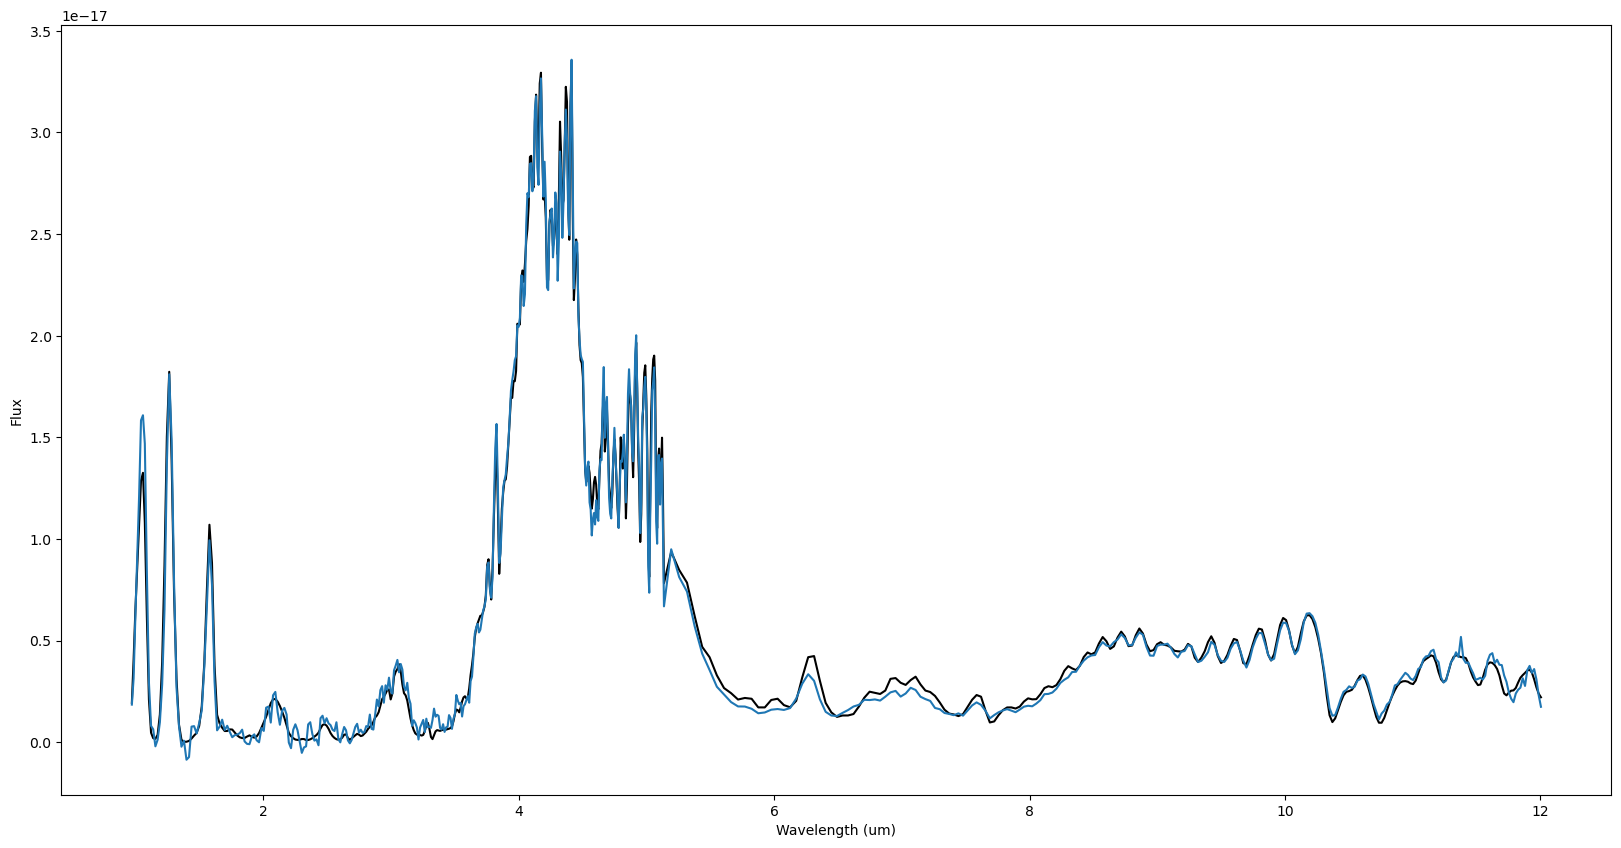

In [20]:
R = obspec[-1, :]
modspec = conv_non_uniform_R(obspec, shiftspec, R)
fig, ax_mod = plt.subplots(figsize=(20, 10))
ax_mod.plot(obspec[0, :], modspec, color='k')
ax_mod.plot(obspec[0, :], obspec[1, :])
ax_mod.set_xlabel('Wavelength (um)')
ax_mod.set_ylabel('Flux')
#plt.legend()
plt.show()